In [2]:
pip install tf_keras

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 7.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install --upgrade pip setuptools wheel

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
Using cached wheel-0.46.3-py3-none-any.whl (30 kB)
  Attempting uninstall: wheel
    Found existing installation: wheel 0.45.1
    Uninstalling wheel-0.45.1:
      Successfully uninstalled wheel-0.45.1
  Attempting uninstall: setuptools
    Found existing installation: setuptools 79.0.1
    Uninstalling setuptools-79.0.1:
      Successfully uninstalled setuptools-79.0.1
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.11.0 requires setuptools<82, but you have setuptools 82.0.1 which is incompatible.


In [8]:
pip install "transformers<5.0" "setfit>=1.1.0" datasets

  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.0 MB 9.1 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/12.0 MB 10.0 MB/s eta 0:00:01
   ------------- -------------------------- 3.9/12.0 MB 10.0 MB/s eta 0:00:01
   ------------------- -------------------- 5.8/12.0 MB 6.9 MB/s eta 0:00:01
   ------------------------ --------------- 7.3/12.0 MB 7.1 MB/s eta 0:00:01
   ------------------------------ --------- 9.2/12.0 MB 7.5 MB/s eta 0:00:01
   ------------------------------ --------- 9.2/12.0 MB 7.5 MB/s eta 0:00:01
   ----------------------------------- ---- 10.7/12.0 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------  11.8/12.0 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 12.0/12.0 MB 5.8 MB/s  0:00:02
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)

  Attempting uninstall:

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
import numpy as np
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
import string
import re
import os
from string import digits
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import datetime
import csv

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras.layers import Embedding, Dense, LSTM, Input
from tensorflow.keras.models import Model
from keras.utils import plot_model

In [9]:
df = pd.read_csv('archive/political_Bias.csv' , encoding = 'utf-8')
df.head()

,Title,Link,Text,Source,Bias
0,John Boltonâ€™s Advice for the â€˜Continuing T...,https://thedispatch.com/article/john-boltons-a...,"With just days until his inauguration, it woul...",TheDispatch,lean right
1,Why Shrubland Makes Southern Californiaâ€™s Wi...,https://thedispatch.com/newsletter/techne/why-...,"Welcome back to Techne! In Star Trek, writers ...",TheDispatch,lean right
2,Los Angelesâ€™ Destruction Was Fueled by Bad P...,https://thedispatch.com/newsletter/capitolism/...,"As fire still rages in the Los Angeles area, I...",TheDispatch,lean right
3,Acquiring Greenland Is a Good Idea. Threatenin...,https://thedispatch.com/article/acquiring-gree...,"Whether it was Will Rogers or Tony Soprano, th...",TheDispatch,lean right
4,Assessing Trumpâ€™s Expansionist Designs,https://thedispatch.com/newsletter/morning/ass...,"Happy Friday! If anyone was wondering, Belgium...",TheDispatch,lean right


In [10]:
df[df.isna().any(axis=1)]

,Title,Link,Text,Source,Bias
16,Biden pardons his family in final minutes in o...,https://www.cnbc.com/2025/01/20/biden-pardons-...,NaN,cnbc,center
17,"Biden pardons Dr. Anthony Fauci, Gen. Milley, ...",https://www.cnbc.com/2025/01/20/biden-pardons-...,NaN,cnbc,center
19,"As America braces for Trump 2.0, here's how th...",https://www.cnbc.com/2025/01/20/how-the-rest-o...,NaN,cnbc,center
25,Trump says he's thinking of imposing 25% tarif...,https://www.cnbc.com/2025/01/20/trump-says-hes...,NaN,cnbc,center
26,Trump's crypto-frenzied inauguration weekend m...,https://www.cnbc.com/2025/01/20/trump-crypto-f...,NaN,cnbc,center
...,...,...,...,...,...
2723,Four female Israeli hostages released by Hamas...,https://www.nbcnews.com/news/world/live-blog/h...,NaN,nbcnews,lean left
2725,Trump Day 7 dropdown with sub links,https://www.nbcnews.com/politics/donald-trump/...,NaN,nbcnews,lean left
2726,NFL playoffs dropdown with sub links,https://www.nbcnews.com/sports/nfl/live-blog/n...,NaN,nbcnews,lean left
2727,Live updates: Eagles beat the Commanders 55-23...,https://www.nbcnews.com/sports/nfl/live-blog/n...,NaN,nbcnews,lean left


In [17]:
df['Text'] = df['Text'].fillna("Textmissing")

punctuation_set = {
    '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', 
    ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~',
    '।', '“', '”', '‘', '’', '॥', '…', '॰'
}

df['Text'] = df['Text'].apply(lambda x: ''.join(ch for ch in x if ch not in punctuation_set))

remove_digits = str.maketrans('', '', digits)
df['Text'] = df['Text'].apply(lambda x: x.translate(remove_digits))
df['Text']=df['Text'].apply(lambda x: x.strip())
df['Text'] = df['Text'].apply(lambda x: re.sub(r'\s+', ' ', x))
df['Text'] = df['Text'].apply(lambda x: x.lower())
df['Text_seq_length'] = df['Text'].apply(lambda x: len(x.split(' ')))
df.head(3)

,Title,Link,Text,Source,Bias,Text_seq_length
0,John Boltonâ€™s Advice for the â€˜Continuing T...,https://thedispatch.com/article/john-boltons-a...,with just days until his inauguration it would...,TheDispatch,lean right,1015
1,Why Shrubland Makes Southern Californiaâ€™s Wi...,https://thedispatch.com/newsletter/techne/why-...,welcome back to techne in star trek writers go...,TheDispatch,lean right,2023
2,Los Angelesâ€™ Destruction Was Fueled by Bad P...,https://thedispatch.com/newsletter/capitolism/...,as fire still rages in the los angeles area iâ...,TheDispatch,lean right,338


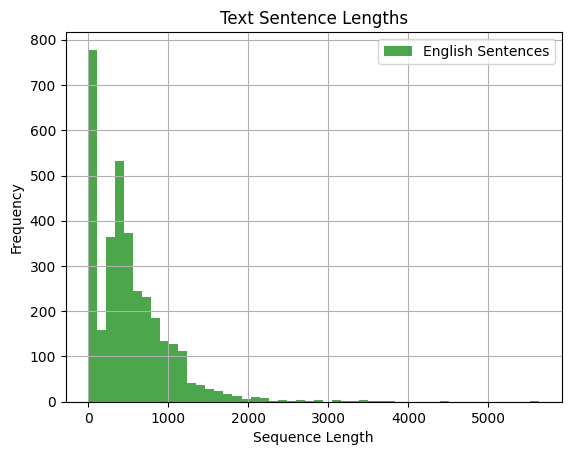

In [18]:
df.hist(column="Text_seq_length", bins=50, alpha=0.7, color='green', label='English Sentences')
plt.title('Text Sentence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.show()

In [19]:
df[df['Text_seq_length']>1000].shape

(479, 6)

In [20]:
df = df[df['Text_seq_length']<1000]
df.shape

(2978, 6)

In [21]:
Text_sentences = df['Text'].apply(lambda x: x+' END')

In [22]:
Text_tokenizer = Tokenizer(filters='')
Text_tokenizer.fit_on_texts(Text_sentences)
num_encoder_tokens = len(Text_tokenizer.word_index) + 1

In [23]:
Text_sequences = Text_tokenizer.texts_to_sequences(Text_sentences)

In [24]:
with open('Text_tokenizer.pkl', 'wb') as f:
    pickle.dump(Text_tokenizer, f)

SetFit methods

In [ ]:
import pandas as pd
from datasets import Dataset
from setfit import SetFitModel, Trainer, TrainingArguments

df = pd.read_csv('archive/Political_Bias.csv')

# Pre-process the data
df['text'] = df['Title'].fillna('') + " " + df['Text'].fillna('')

(SetFit requirement)
label_map = {
    'left': 0, 
    'lean left': 1, 
    'center': 2, 
    'lean right': 3, 
    'right': 4
}
df['label'] = df['Bias'].str.lower().map(label_map)

# Remove any rows with missing labels if they exist
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# Convert to HuggingFace Dataset format
full_dataset = Dataset.from_pandas(df[['text', 'label']])
dataset_split = full_dataset.train_test_split(test_size=0.2)
train_dataset = dataset_split['train']
eval_dataset = dataset_split['test']

# Load Local Sentence Transformer
model = SetFitModel.from_pretrained("sentence-transformers/paraphrase-mpnet-base-v2")

# Training Arguments
args = TrainingArguments(
    batch_size=16,
    num_epochs=1,          # SetFit only needs 1 epoch for contrastive learning
    use_amp=True,          # Uses Mixed Precision if using an NVIDIA GPU
)

# Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    column_mapping={"text": "text", "label": "label"},
)

# Train and Save
print("Starting local training...")
trainer.train()

# Evaluate accuracy
metrics = trainer.evaluate()
print(f"Model Accuracy: {metrics['accuracy'] * 100:.2f}%")

# Save the model locally
model.save_pretrained("news_bias_setfit_model")

# (Testing a new article)
new_news = "The senate passed a landmark climate bill today despite heavy opposition."
probs = model.predict_proba([new_news])

# Format output
output_label = model.predict([new_news])[0]
reverse_map = {v: k for k, v in label_map.items()}
confidence = probs[0][output_label].item()

print(f"Predicted Bias: {reverse_map[output_label]}")
print(f"Confidence Score: {confidence:.4f}")

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Map: 100%|██████████| 2766/2766 [00:00<00:00, 5528.04 examples/s]


Starting local training...


ArrowMemoryError: realloc of size 3330277376 failed